In [ ]:
## Fashion-MNIST (10 Clothing Classes)

In [ ]:
## Baseline 2-Layer CNN (No Augmentation)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

# Load dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize
x_train = x_train.reshape(-1,28,28,1)/255.0
x_test = x_test.reshape(-1,28,28,1)/255.0

y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

# 2-layer CNN
model = models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(10,activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train,y_train,epochs=10,
                    validation_data=(x_test,y_test))

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 63s 33ms/step - accuracy: 0.7805 - loss: 0.6103 - val_accuracy: 0.8784 - val_loss: 0.3374
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.8875 - loss: 0.3085 - val_accuracy: 0.8862 - val_loss: 0.3116
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.9061 - loss: 0.2563 - val_accuracy: 0.9032 - val_loss: 0.2664
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - accuracy: 0.9184 - loss: 0.2189 - val_accuracy: 0.8994 - val_loss: 0.2691
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 30ms/step - accuracy: 0.9292 - loss: 0.1889 - val_accuracy: 0.9098 - val_loss: 0.2408
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - accuracy: 0.9378 - loss: 0.1677 - val_accuracy: 0.9112 - val_loss: 0.2525
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 30ms/step - accuracy: 0.9463 - loss: 0.1454 - val_accuracy: 0.9109 - val_loss: 0.2599
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 29ms/step - accuracy: 0.9524 -

In [ ]:
## With Data Augmentation

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

datagen.fit(x_train)

history_aug = model.fit(datagen.flow(x_train,y_train,batch_size=64),
                        epochs=10,
                        validation_data=(x_test,y_test))

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


938/938 ━━━━━━━━━━━━━━━━━━━━ 69s 73ms/step - accuracy: 0.8071 - loss: 0.5300 - val_accuracy: 0.8975 - val_loss: 0.2815
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 80s 71ms/step - accuracy: 0.8570 - loss: 0.3789 - val_accuracy: 0.9079 - val_loss: 0.2674
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 71ms/step - accuracy: 0.8655 - loss: 0.3556 - val_accuracy: 0.8958 - val_loss: 0.2925
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 66s 71ms/step - accuracy: 0.8740 - loss: 0.3364 - val_accuracy: 0.9072 - val_loss: 0.2634
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 69s 73ms/step - accuracy: 0.8788 - loss: 0.3232 - val_accuracy: 0.9026 - val_loss: 0.2728
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 71s 76ms/step - accuracy: 0.8837 - loss: 0.3093 - val_accuracy: 0.9046 - val_loss: 0.2620
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 71s 76ms/step - accuracy: 0.8851 - loss: 0.3010 - val_accuracy: 0.8962 - val_loss: 0.2853
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 85s 90ms/step - accuracy: 0.8884 - loss: 0.2963 - val_accurac

# **ASSIGNMENT 2: MNIST DIGITS**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.datasets import mnist
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.19.0


In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training shape:", x_train.shape)
print("Test shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


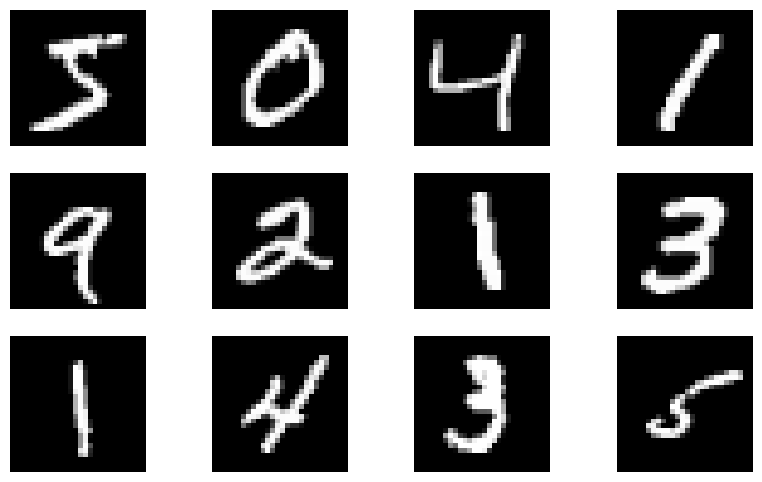

In [ ]:
plt.figure(figsize=(10,6))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.axis('off')
plt.show()

In [ ]:
x_train = x_train.reshape(-1,28,28,1)/255.0
x_test = x_test.reshape(-1,28,28,1)/255.0

y_train_cat = to_categorical(y_train,10)
y_test_cat = to_categorical(y_test,10)

In [ ]:
def build_model():
    model = models.Sequential([
        layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(64,(3,3),activation='relu'),
        layers.MaxPooling2D(2,2),
        layers.Flatten(),
        layers.Dense(128,activation='relu'),
        layers.Dense(10,activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model_base = build_model()
model_base.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_base = model_base.fit(
    x_train, y_train_cat,
    epochs=10,
    validation_data=(x_test,y_test_cat),
    batch_size=64
)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 61s 62ms/step - accuracy: 0.8899 - loss: 0.3684 - val_accuracy: 0.9816 - val_loss: 0.0514
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 56s 60ms/step - accuracy: 0.9841 - loss: 0.0525 - val_accuracy: 0.9869 - val_loss: 0.0375
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 48s 52ms/step - accuracy: 0.9898 - loss: 0.0337 - val_accuracy: 0.9903 - val_loss: 0.0294
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 63s 67ms/step - accuracy: 0.9930 - loss: 0.0220 - val_accuracy: 0.9904 - val_loss: 0.0263
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 50s 53ms/step - accuracy: 0.9949 - loss: 0.0161 - val_accuracy: 0.9903 - val_loss: 0.0284
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 53ms/step - accuracy: 0.9954 - loss: 0.0137 - val_accuracy: 0.9923 - val_loss: 0.0239
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 79s 50ms/step - accuracy: 0.9967 - loss: 0.0113 - val_accuracy: 0.9920 - val_loss: 0.0258
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 50s 54ms/step - accuracy: 0.9979 - loss: 0.0076 - 

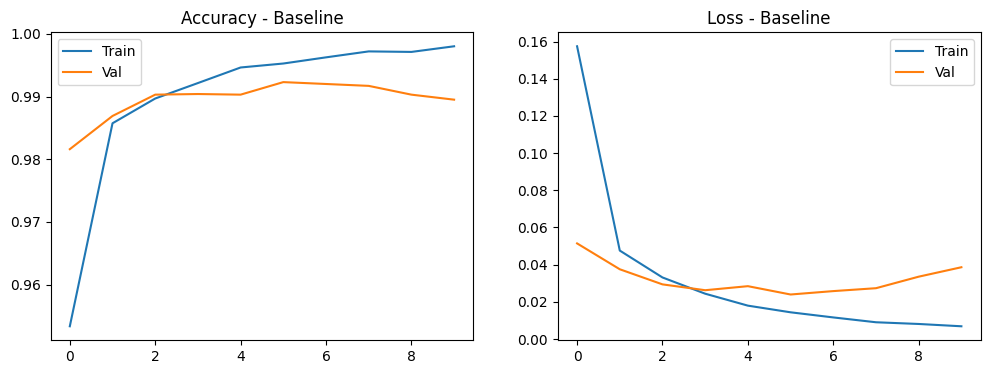

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_base.history['accuracy'], label='Train')
plt.plot(history_base.history['val_accuracy'], label='Val')
plt.title("Accuracy - Baseline")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_base.history['loss'], label='Train')
plt.plot(history_base.history['val_loss'], label='Val')
plt.title("Loss - Baseline")
plt.legend()

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


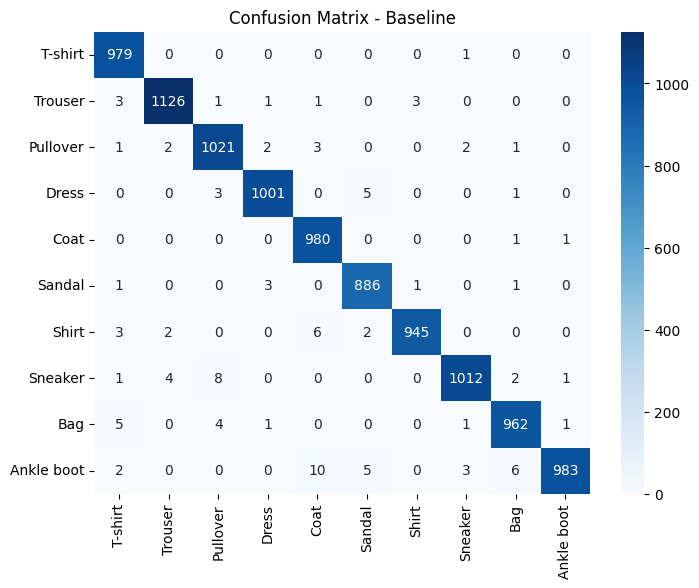

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.98      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.98      0.99      1028
           8       0.99      0.99      0.99       974
           9       1.00      0.97      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [ ]:
y_pred = model_base.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Confusion Matrix - Baseline")
plt.show()

print(classification_report(y_test, y_pred_classes))

In [ ]:
datagen = ImageDataGenerator(rotation_range=10, zoom_range=0.1)

datagen.fit(x_train)

In [ ]:
model_aug = build_model()

history_aug = model_aug.fit(
    datagen.flow(x_train, y_train_cat, batch_size=64),
    epochs=10,
    validation_data=(x_test,y_test_cat)
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 70s 72ms/step - accuracy: 0.8747 - loss: 0.4102 - val_accuracy: 0.9839 - val_loss: 0.0472
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 71ms/step - accuracy: 0.9784 - loss: 0.0665 - val_accuracy: 0.9898 - val_loss: 0.0326
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 70s 74ms/step - accuracy: 0.9851 - loss: 0.0463 - val_accuracy: 0.9896 - val_loss: 0.0323
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 64s 68ms/step - accuracy: 0.9879 - loss: 0.0397 - val_accuracy: 0.9905 - val_loss: 0.0267
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 64s 68ms/step - accuracy: 0.9907 - loss: 0.0298 - val_accuracy: 0.9911 - val_loss: 0.0260
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 69ms/step - accuracy: 0.9920 - loss: 0.0255 - val_accuracy: 0.9920 - val_loss: 0.0252
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 64s 68ms/step - accuracy: 0.9925 - loss: 0.0217 - val_accuracy: 0.9890 - val_loss: 0.0326
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 66s 71ms/step - accuracy: 0.9940 - loss: 0.0178 - 

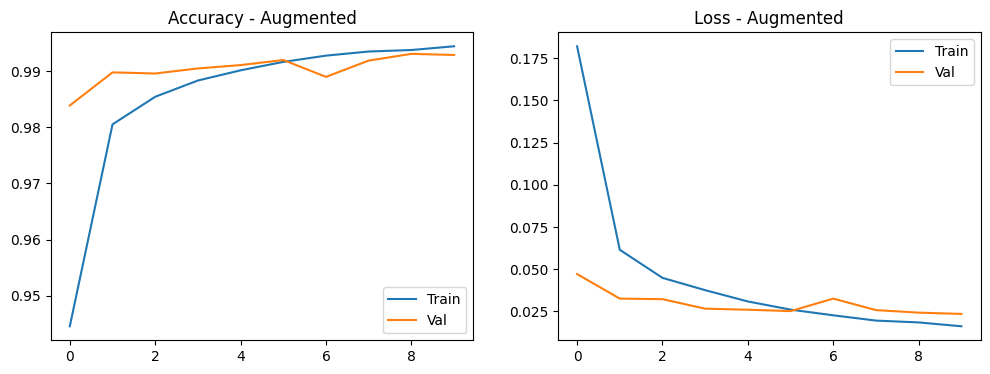

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_aug.history['accuracy'], label='Train')
plt.plot(history_aug.history['val_accuracy'], label='Val')
plt.title("Accuracy - Augmented")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_aug.history['loss'], label='Train')
plt.plot(history_aug.history['val_loss'], label='Val')
plt.title("Loss - Augmented")
plt.legend()

plt.show()

In [ ]:
base_acc = history_base.history['val_accuracy'][-1]
aug_acc = history_aug.history['val_accuracy'][-1]

print("Baseline Accuracy:", base_acc)
print("Augmented Accuracy:", aug_acc)

Baseline Accuracy: 0.9894999861717224
Augmented Accuracy: 0.992900013923645


# ASSIGNMENT 3: CIFAR-**100**

In [ ]:
(x_train, y_train), (x_test, y_test) = cifar100.load_data()

print("Training shape:", x_train.shape)
print("Test shape:", x_test.shape)
print("Number of classes:", len(np.unique(y_train)))

Training shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)
Number of classes: 100


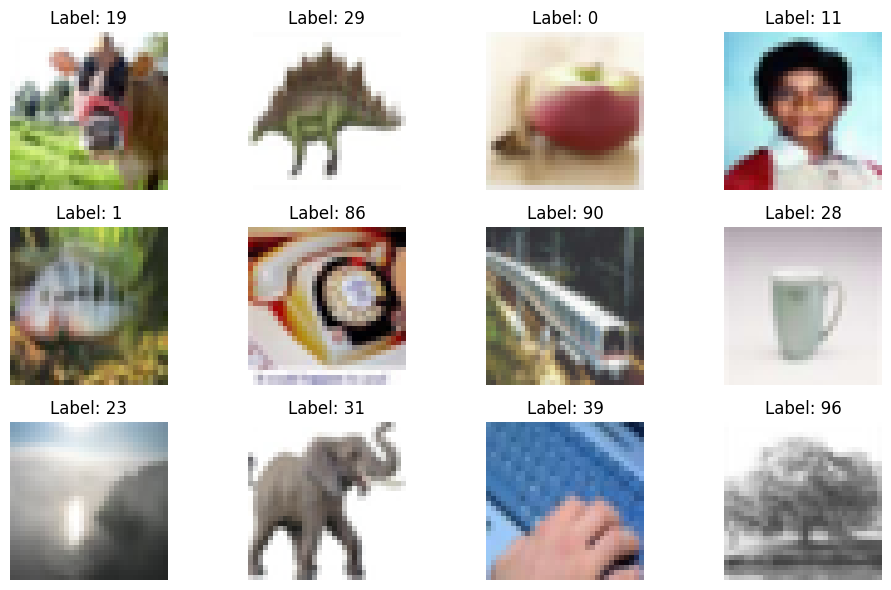

In [ ]:
plt.figure(figsize=(10,6))

for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(x_train[i])
    plt.title("Label: " + str(y_train[i][0]))
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Normalize pixel values
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encode labels
y_train_cat = to_categorical(y_train, 100)
y_test_cat = to_categorical(y_test, 100)

print("After preprocessing:")
print("x_train:", x_train.shape)
print("y_train:", y_train_cat.shape)

After preprocessing:
x_train: (50000, 32, 32, 3)
y_train: (50000, 100)


In [ ]:
def build_model():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(100, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

model_base = build_model()
model_base.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 635,172 (2.42 MB)

 Trainable params: 635,172 (2.42 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
history_base = model_base.fit(
    x_train, y_train_cat,
    epochs=20,
    batch_size=64,
    validation_data=(x_test, y_test_cat)
)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 80s 103ms/step - accuracy: 0.9106 - loss: 0.2944 - val_accuracy: 0.3513 - val_loss: 5.1643
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 66s 83ms/step - accuracy: 0.9176 - loss: 0.2686 - val_accuracy: 0.3389 - val_loss: 5.5412
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 64s 82ms/step - accuracy: 0.9172 - loss: 0.2608 - val_accuracy: 0.3468 - val_loss: 5.6857
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 83ms/step - accuracy: 0.9340 - loss: 0.2139 - val_accuracy: 0.3384 - val_loss: 6.0353
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 84ms/step - accuracy: 0.9330 - loss: 0.2063 - val_accuracy: 0.3476 - val_loss: 6.3344
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 63s 81ms/step - accuracy: 0.9417 - loss: 0.1829 - val_accuracy: 0.3474 - val_loss: 6.5568
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 64s 82ms/step - accuracy: 0.9382 - loss: 0.1928 - val_accuracy: 0.3451 - val_loss: 6.7702
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 83ms/step - accuracy: 0.9445 - loss: 0.1712 -

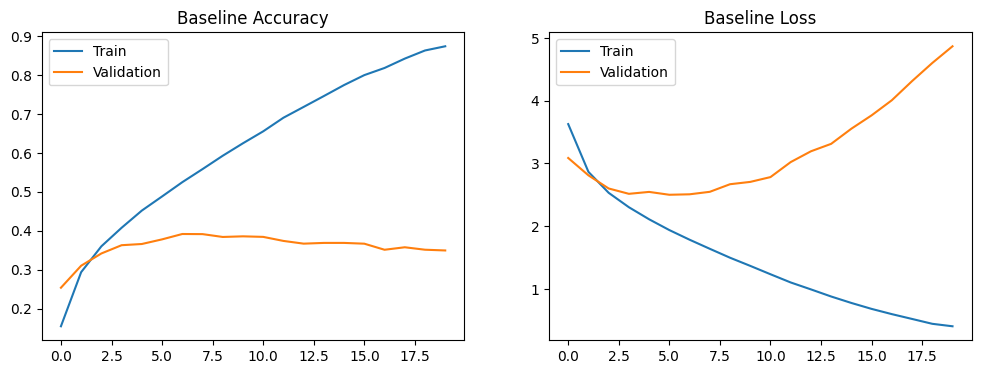

In [27]:
plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_base.history['accuracy'], label='Train')
plt.plot(history_base.history['val_accuracy'], label='Validation')
plt.title("Baseline Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history_base.history['loss'], label='Train')
plt.plot(history_base.history['val_loss'], label='Validation')
plt.title("Baseline Loss")
plt.legend()

plt.show()

In [28]:
test_loss_base, test_acc_base = model_base.evaluate(x_test, y_test_cat)
print("Baseline Test Accuracy:", test_acc_base)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.3462 - loss: 4.8512
Baseline Test Accuracy: 0.34950000047683716


313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step


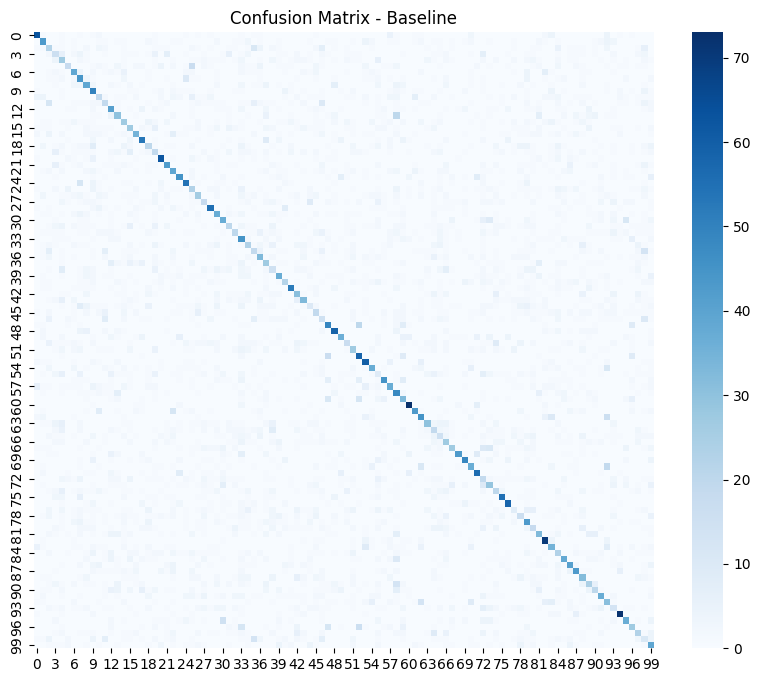

In [35]:
y_pred_base = model_base.predict(x_test)
y_pred_classes_base = np.argmax(y_pred_base, axis=1)

cm_base = confusion_matrix(y_test.flatten(), y_pred_classes_base)

plt.figure(figsize=(10,8))
sns.heatmap(cm_base, cmap='Blues')
plt.title("Confusion Matrix - Baseline")
plt.show()

In [31]:
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

datagen.fit(x_train)

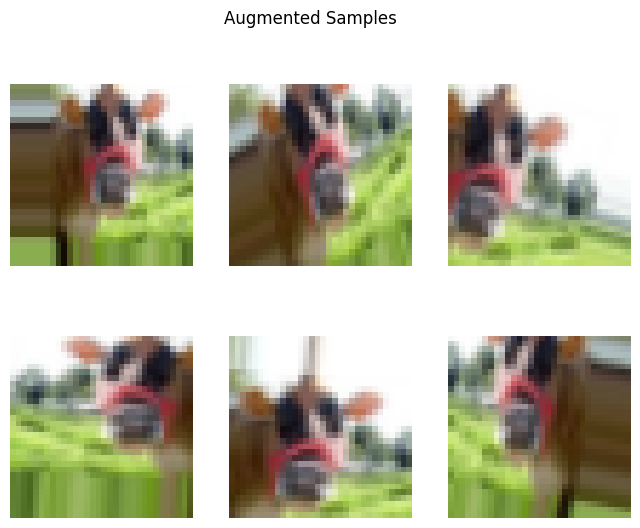

In [32]:
sample = x_train[:1]

plt.figure(figsize=(8,6))

for i, batch in enumerate(datagen.flow(sample, batch_size=1)):
    plt.subplot(2,3,i+1)
    plt.imshow(batch[0])
    plt.axis('off')
    if i == 5:
        break

plt.suptitle("Augmented Samples")
plt.show()

In [33]:
model_aug = build_model()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
history_aug = model_aug.fit(
    datagen.flow(x_train, y_train_cat, batch_size=64),
    epochs=5,
    validation_data=(x_test, y_test_cat)
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 104s 132ms/step - accuracy: 0.0786 - loss: 4.0617 - val_accuracy: 0.1907 - val_loss: 3.3974
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 94s 120ms/step - accuracy: 0.1654 - loss: 3.5074 - val_accuracy: 0.2366 - val_loss: 3.1249
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 90s 116ms/step - accuracy: 0.2047 - loss: 3.2765 - val_accuracy: 0.2685 - val_loss: 2.9320
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 93s 118ms/step - accuracy: 0.2275 - loss: 3.1529 - val_accuracy: 0.2911 - val_loss: 2.8392
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 93s 119ms/step - accuracy: 0.2470 - loss: 3.0610 - val_accuracy: 0.3059 - val_loss: 2.7639


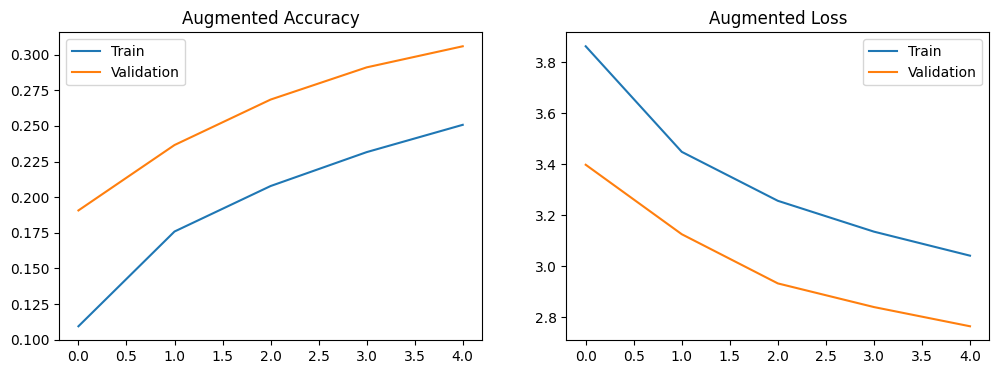

In [37]:
plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_aug.history['accuracy'], label='Train')
plt.plot(history_aug.history['val_accuracy'], label='Validation')
plt.title("Augmented Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history_aug.history['loss'], label='Train')
plt.plot(history_aug.history['val_loss'], label='Validation')
plt.title("Augmented Loss")
plt.legend()

plt.show()

In [38]:
test_loss_aug, test_acc_aug = model_aug.evaluate(x_test, y_test_cat)
print("Augmented Test Accuracy:", test_acc_aug)

313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 53ms/step - accuracy: 0.3118 - loss: 2.7557
Augmented Test Accuracy: 0.3059000074863434


Baseline Accuracy : 0.34950000047683716
Augmented Accuracy: 0.3059000074863434


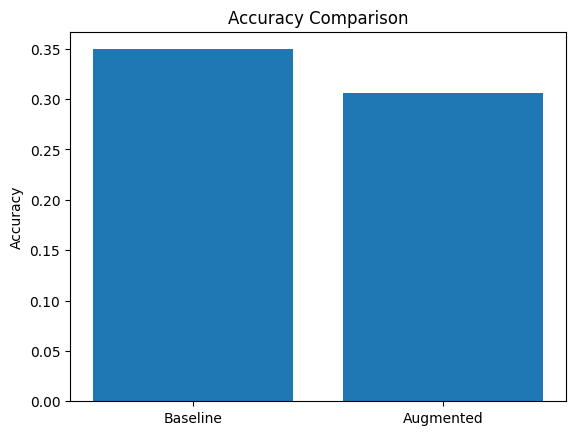

In [39]:
print("Baseline Accuracy :", test_acc_base)
print("Augmented Accuracy:", test_acc_aug)

plt.bar(['Baseline','Augmented'], [test_acc_base, test_acc_aug])
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

# ASSIGNMENT 4: Pneumonia Dataset

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"srajankushwaha","key":"8a8eec217fb02b689923d019df5cdf4e"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
 98% 2.25G/2.29G [00:23<00:01, 39.3MB/s]
100% 2.29G/2.29G [00:23<00:00, 105MB/s] 


In [4]:
!unzip chest-xray-pneumonia.zip

Streaming output truncated to the last 5000 lines.
  inflating: chest_xray/train/NORMAL/IM-0435-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0435-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0438-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0440-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0441-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0442-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0444-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0445-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0446-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0447-0001.jpeg  
  inflating:

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.19.0


In [6]:
train_path = "chest_xray/train"
test_path = "chest_xray/test"
val_path = "chest_xray/val"

In [7]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


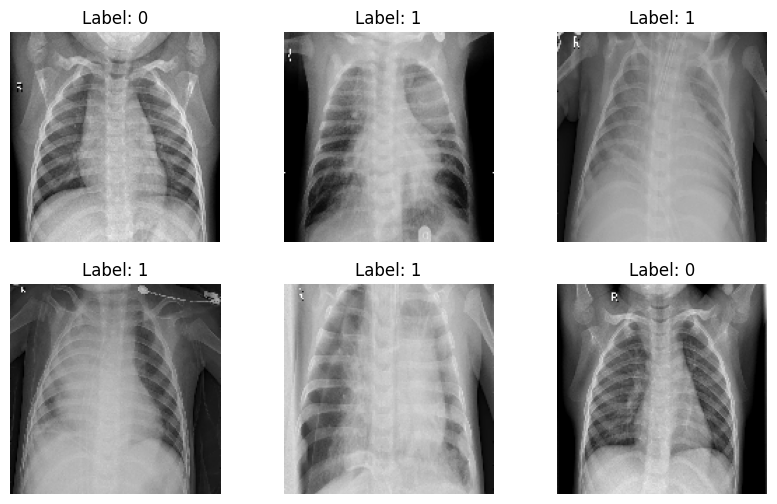

In [8]:
images, labels = next(train_generator)

plt.figure(figsize=(10,6))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.title("Label: " + str(int(labels[i])))
    plt.axis('off')
plt.show()

In [9]:
def build_model():
    model = models.Sequential([
        layers.Conv2D(32,(3,3),activation='relu',input_shape=(150,150,3)),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64,(3,3),activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128,(3,3),activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128,(3,3),activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(512,activation='relu'),
        layers.Dense(1,activation='sigmoid')
    ])

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    return model

model_base = build_model()
model_base.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history_base = model_base.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 63s 345ms/step - accuracy: 0.7867 - loss: 0.4865 - val_accuracy: 0.7740 - val_loss: 0.6816
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 49s 300ms/step - accuracy: 0.9465 - loss: 0.1353 - val_accuracy: 0.8269 - val_loss: 0.4999
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 48s 296ms/step - accuracy: 0.9576 - loss: 0.1053 - val_accuracy: 0.7869 - val_loss: 0.7759
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 48s 294ms/step - accuracy: 0.9729 - loss: 0.0735 - val_accuracy: 0.7452 - val_loss: 0.9024
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 48s 294ms/step - accuracy: 0.9774 - loss: 0.0630 - val_accuracy: 0.7997 - val_loss: 0.8604
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 48s 294ms/step - accuracy: 0.9821 - loss: 0.0494 - val_accuracy: 0.7580 - val_loss: 1.4047
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 47s 288ms/step - accuracy: 0.9824 - loss: 0.0421 - val_accuracy: 0.7548 - val_loss: 1.3556
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 48s 295ms/step - accuracy: 0.9794 - loss: 0

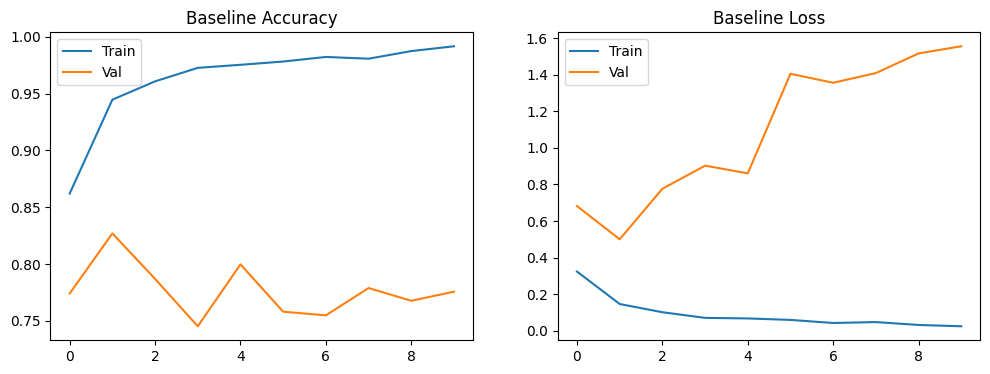

In [11]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_base.history['accuracy'], label='Train')
plt.plot(history_base.history['val_accuracy'], label='Val')
plt.title("Baseline Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_base.history['loss'], label='Train')
plt.plot(history_base.history['val_loss'], label='Val')
plt.title("Baseline Loss")
plt.legend()

plt.show()

In [12]:
baseline_loss, baseline_acc = model_base.evaluate(test_generator)
print("Baseline Accuracy:", baseline_acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 234ms/step - accuracy: 0.7949 - loss: 1.3835
Baseline Accuracy: 0.7756410241127014


In [13]:
train_datagen_aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

train_generator_aug = train_datagen_aug.flow_from_directory(
    train_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.


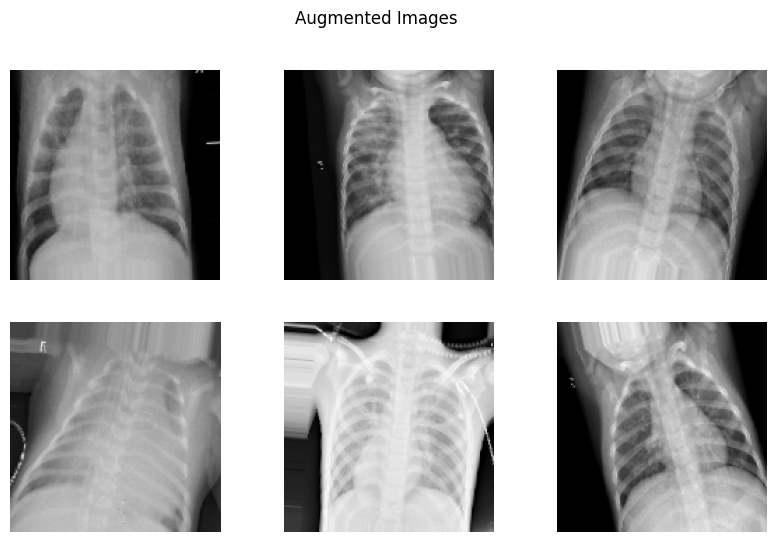

In [14]:
sample_img, _ = next(train_generator_aug)

plt.figure(figsize=(10,6))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(sample_img[i])
    plt.axis('off')
plt.suptitle("Augmented Images")
plt.show()

In [15]:
model_aug = build_model()

In [17]:
history_aug = model_aug.fit(
    train_generator_aug,
    epochs=5,
    validation_data=test_generator
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 72s 443ms/step - accuracy: 0.7770 - loss: 0.5003 - val_accuracy: 0.8446 - val_loss: 0.3549
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 436ms/step - accuracy: 0.8776 - loss: 0.2772 - val_accuracy: 0.8750 - val_loss: 0.3105
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 70s 431ms/step - accuracy: 0.9080 - loss: 0.2240 - val_accuracy: 0.8542 - val_loss: 0.4172
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 439ms/step - accuracy: 0.9328 - loss: 0.1643 - val_accuracy: 0.8317 - val_loss: 0.4825
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 437ms/step - accuracy: 0.9416 - loss: 0.1552 - val_accuracy: 0.8990 - val_loss: 0.3484


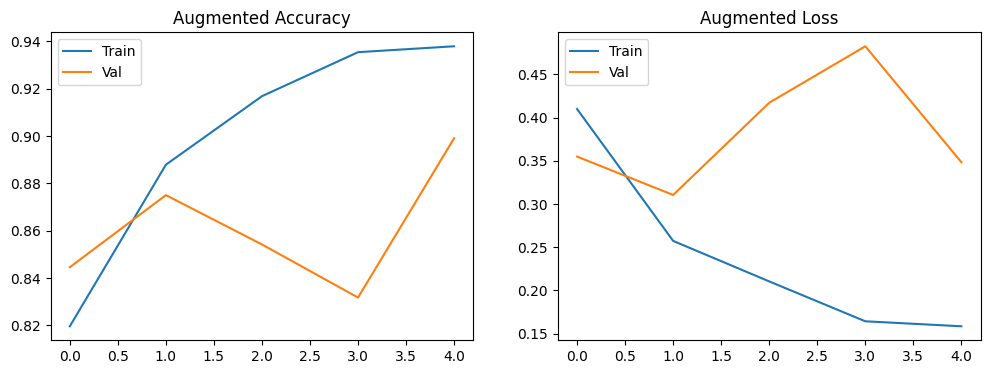

In [18]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_aug.history['accuracy'], label='Train')
plt.plot(history_aug.history['val_accuracy'], label='Val')
plt.title("Augmented Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_aug.history['loss'], label='Train')
plt.plot(history_aug.history['val_loss'], label='Val')
plt.title("Augmented Loss")
plt.legend()

plt.show()

In [19]:
aug_loss, aug_acc = model_aug.evaluate(test_generator)
print("Augmented Accuracy:", aug_acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 255ms/step - accuracy: 0.9021 - loss: 0.3101
Augmented Accuracy: 0.8990384340286255


Baseline Accuracy : 0.7756410241127014
Augmented Accuracy: 0.8990384340286255


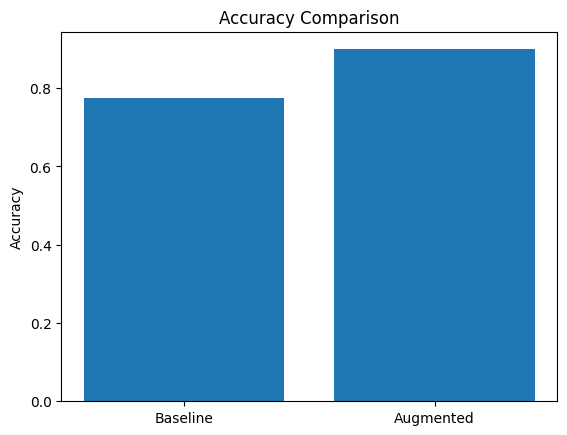

In [20]:
print("Baseline Accuracy :", baseline_acc)
print("Augmented Accuracy:", aug_acc)

plt.bar(['Baseline','Augmented'], [baseline_acc, aug_acc])
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

# ASSIGNMENT 4: Pneumonia Dataset

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"srajankushwaha","key":"8a8eec217fb02b689923d019df5cdf4e"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
 98% 2.25G/2.29G [00:23<00:01, 39.3MB/s]
100% 2.29G/2.29G [00:23<00:00, 105MB/s] 


In [4]:
!unzip chest-xray-pneumonia.zip

Streaming output truncated to the last 5000 lines.
  inflating: chest_xray/train/NORMAL/IM-0435-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0435-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0438-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0440-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0441-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0442-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0444-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0445-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0446-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0447-0001.jpeg  
  inflating:

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.19.0


In [6]:
train_path = "chest_xray/train"
test_path = "chest_xray/test"
val_path = "chest_xray/val"

In [7]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


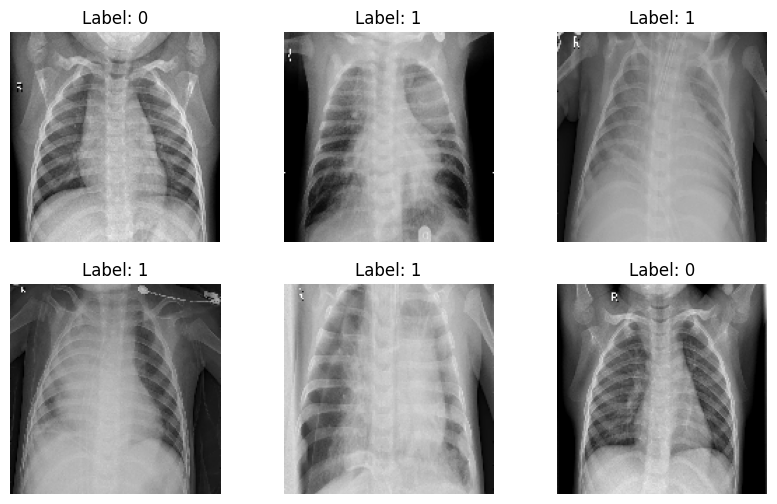

In [8]:
images, labels = next(train_generator)

plt.figure(figsize=(10,6))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.title("Label: " + str(int(labels[i])))
    plt.axis('off')
plt.show()

In [9]:
def build_model():
    model = models.Sequential([
        layers.Conv2D(32,(3,3),activation='relu',input_shape=(150,150,3)),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64,(3,3),activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128,(3,3),activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128,(3,3),activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(512,activation='relu'),
        layers.Dense(1,activation='sigmoid')
    ])

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    return model

model_base = build_model()
model_base.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history_base = model_base.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 63s 345ms/step - accuracy: 0.7867 - loss: 0.4865 - val_accuracy: 0.7740 - val_loss: 0.6816
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 49s 300ms/step - accuracy: 0.9465 - loss: 0.1353 - val_accuracy: 0.8269 - val_loss: 0.4999
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 48s 296ms/step - accuracy: 0.9576 - loss: 0.1053 - val_accuracy: 0.7869 - val_loss: 0.7759
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 48s 294ms/step - accuracy: 0.9729 - loss: 0.0735 - val_accuracy: 0.7452 - val_loss: 0.9024
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 48s 294ms/step - accuracy: 0.9774 - loss: 0.0630 - val_accuracy: 0.7997 - val_loss: 0.8604
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 48s 294ms/step - accuracy: 0.9821 - loss: 0.0494 - val_accuracy: 0.7580 - val_loss: 1.4047
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 47s 288ms/step - accuracy: 0.9824 - loss: 0.0421 - val_accuracy: 0.7548 - val_loss: 1.3556
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 48s 295ms/step - accuracy: 0.9794 - loss: 0

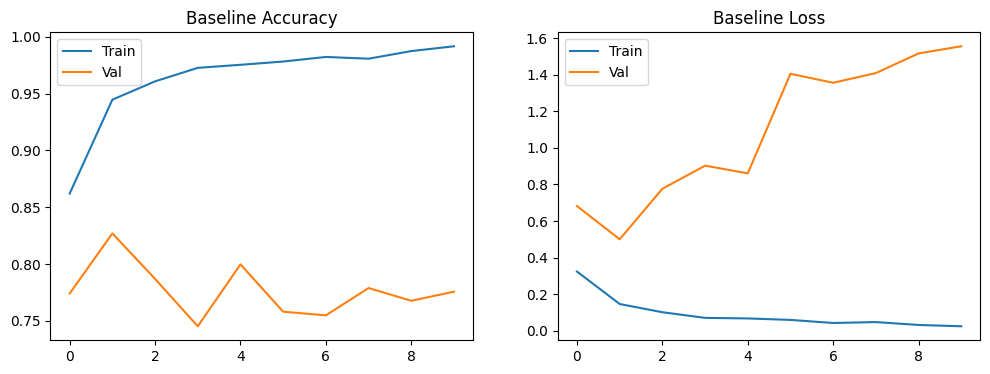

In [11]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_base.history['accuracy'], label='Train')
plt.plot(history_base.history['val_accuracy'], label='Val')
plt.title("Baseline Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_base.history['loss'], label='Train')
plt.plot(history_base.history['val_loss'], label='Val')
plt.title("Baseline Loss")
plt.legend()

plt.show()

In [12]:
baseline_loss, baseline_acc = model_base.evaluate(test_generator)
print("Baseline Accuracy:", baseline_acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 234ms/step - accuracy: 0.7949 - loss: 1.3835
Baseline Accuracy: 0.7756410241127014


In [13]:
train_datagen_aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

train_generator_aug = train_datagen_aug.flow_from_directory(
    train_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.


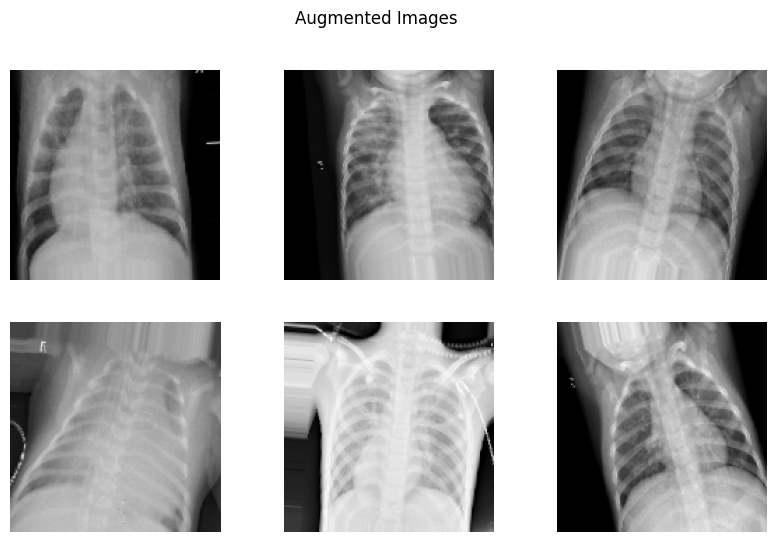

In [14]:
sample_img, _ = next(train_generator_aug)

plt.figure(figsize=(10,6))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(sample_img[i])
    plt.axis('off')
plt.suptitle("Augmented Images")
plt.show()

In [15]:
model_aug = build_model()

In [17]:
history_aug = model_aug.fit(
    train_generator_aug,
    epochs=5,
    validation_data=test_generator
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 72s 443ms/step - accuracy: 0.7770 - loss: 0.5003 - val_accuracy: 0.8446 - val_loss: 0.3549
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 436ms/step - accuracy: 0.8776 - loss: 0.2772 - val_accuracy: 0.8750 - val_loss: 0.3105
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 70s 431ms/step - accuracy: 0.9080 - loss: 0.2240 - val_accuracy: 0.8542 - val_loss: 0.4172
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 439ms/step - accuracy: 0.9328 - loss: 0.1643 - val_accuracy: 0.8317 - val_loss: 0.4825
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 437ms/step - accuracy: 0.9416 - loss: 0.1552 - val_accuracy: 0.8990 - val_loss: 0.3484


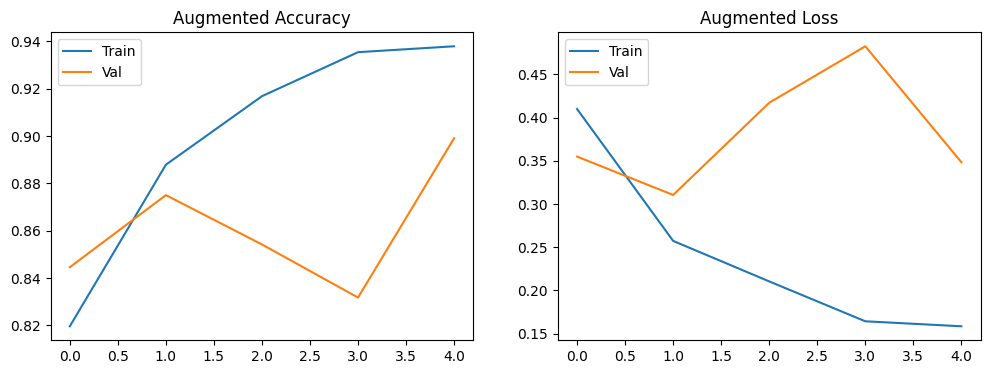

In [18]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_aug.history['accuracy'], label='Train')
plt.plot(history_aug.history['val_accuracy'], label='Val')
plt.title("Augmented Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_aug.history['loss'], label='Train')
plt.plot(history_aug.history['val_loss'], label='Val')
plt.title("Augmented Loss")
plt.legend()

plt.show()

In [19]:
aug_loss, aug_acc = model_aug.evaluate(test_generator)
print("Augmented Accuracy:", aug_acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 255ms/step - accuracy: 0.9021 - loss: 0.3101
Augmented Accuracy: 0.8990384340286255


Baseline Accuracy : 0.7756410241127014
Augmented Accuracy: 0.8990384340286255


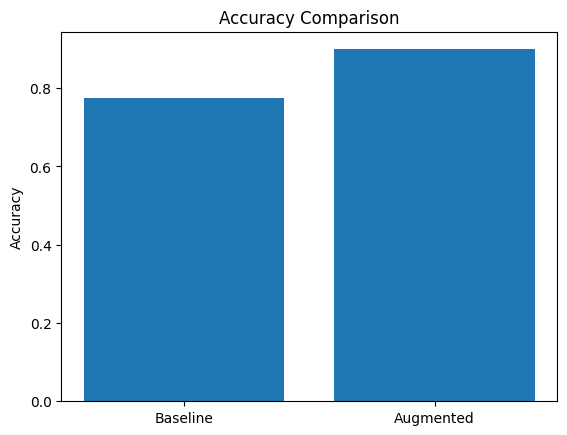

In [20]:
print("Baseline Accuracy :", baseline_acc)
print("Augmented Accuracy:", aug_acc)

plt.bar(['Baseline','Augmented'], [baseline_acc, aug_acc])
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()